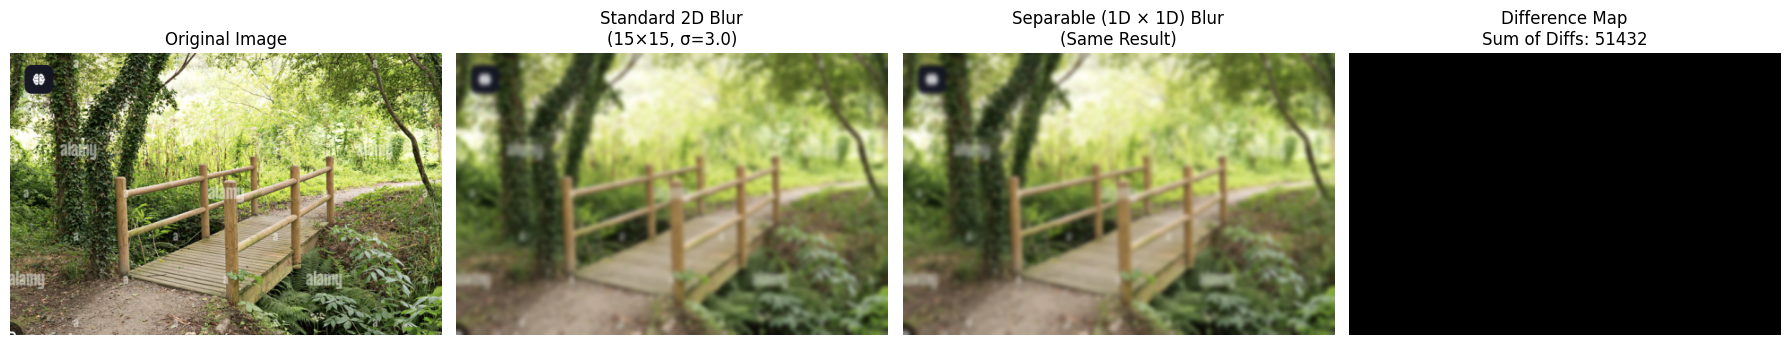

Mathematical Verification: Sum of pixel differences = 51432


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def gaussian_filter_demonstration(image_path):
    # Load the input image
    # Note: OpenCV loads images in BGR format
    bgr_img = cv2.imread(image_path)
    if bgr_img is None:
        print(f"Error: Could not load image from {image_path}")
        return
    
    # Convert to RGB for visualization with Matplotlib
    img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)

    # --- 1. Standard Gaussian Blur ---
    # We use a 15×15 kernel with sigma = 3.0
    k_size = 15
    sigma = 3.0
    standard_2d_blur = cv2.GaussianBlur(img, (k_size, k_size), sigmaX=sigma)

    # --- 2. Demonstrating Separability ---
    # A 2D Gaussian filter is mathematically equivalent to
    # applying a 1D horizontal blur followed by a 1D vertical blur.
    
    # Apply horizontal 1D blur (kernel size 15×1)
    horiz_blur = cv2.GaussianBlur(img, (k_size, 1), sigmaX=sigma)

    # Apply vertical 1D blur (kernel size 1×15)
    separable_blur = cv2.GaussianBlur(horiz_blur, (1, k_size), sigmaX=sigma)

    # --- 3. Verify Equality ---
    # Calculate absolute difference between 2D blur and separable result
    difference = cv2.absdiff(standard_2d_blur, separable_blur)
    diff_sum = np.sum(difference)

    # --- 4. Visualization ---
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 4, 1)
    plt.title("Original Image")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.title(f"Standard 2D Blur\n({k_size}×{k_size}, σ={sigma})")
    plt.imshow(standard_2d_blur)
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.title("Separable (1D × 1D) Blur\n(Same Result)")
    plt.imshow(separable_blur)
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.title(f"Difference Map\nSum of Diffs: {diff_sum}")
    plt.imshow(difference, cmap="hot")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Mathematical Verification: Sum of pixel differences = {diff_sum}")
    if diff_sum < 1.0:  # Allowing small floating-point noise
        print("Success: The 2D Gaussian blur and separable 1D blurs are identical.")

if __name__ == "__main__":
    # Replace 'image.png' with your local file path
    gaussian_filter_demonstration("outdoor.png")
